In [1]:
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
mpl.rcParams['figure.dpi'] = 150

import astropy
from astropy.table import Table, join, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord

import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia

Read in data:

In [2]:
G = 20.5
tab_quaia = Table.read('../data/quaia_G{}.fits'.format(G))
print("Columns:", tab_quaia.columns)
print("N =", len(tab_quaia))

Columns: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>
N = 1295502


In [3]:
# tab_sdss_dr16q = Table.read('../data/SDSS_DR16Q_v4.fits')
tab_sdss_dr16q = Table.read('../data/DR16Q_v4.fits')
tab_sdss_dr16q = tab_sdss_dr16q[tab_sdss_dr16q['OBJID'].mask==False] #remove ones with no objid (1001)
print("Columns:", tab_sdss_dr16q.columns)
print("N =", len(tab_sdss_dr16q))

Columns: <TableColumns names=('SDSS_NAME','RA','DEC','PLATE','MJD','FIBERID','AUTOCLASS_PQN','AUTOCLASS_DR14Q','IS_QSO_QN','Z_QN','RANDOM_SELECT','Z_10K','Z_CONF_10K','PIPE_CORR_10K','IS_QSO_10K','THING_ID','Z_VI','Z_CONF','CLASS_PERSON','Z_DR12Q','IS_QSO_DR12Q','Z_DR7Q_SCH','IS_QSO_DR7Q','Z_DR6Q_HW','Z_DR7Q_HW','IS_QSO_FINAL','Z','SOURCE_Z','Z_PIPE','ZWARNING','OBJID','Z_PCA','ZWARN_PCA','DELTACHI2_PCA','Z_HALPHA','ZWARN_HALPHA','DELTACHI2_HALPHA','Z_HBETA','ZWARN_HBETA','DELTACHI2_HBETA','Z_MGII','ZWARN_MGII','DELTACHI2_MGII','Z_CIII','ZWARN_CIII','DELTACHI2_CIII','Z_CIV','ZWARN_CIV','DELTACHI2_CIV','Z_LYA','ZWARN_LYA','DELTACHI2_LYA','Z_LYAWG','Z_DLA','NHI_DLA','CONF_DLA','BAL_PROB','BI_CIV','ERR_BI_CIV','AI_CIV','ERR_AI_CIV','BI_SIIV','ERR_BI_SIIV','AI_SIIV','ERR_AI_SIIV','BOSS_TARGET1','EBOSS_TARGET0','EBOSS_TARGET1','EBOSS_TARGET2','ANCILLARY_TARGET1','ANCILLARY_TARGET2','NSPEC_SDSS','NSPEC_BOSS','NSPEC','PLATE_DUPLICATE','MJD_DUPLICATE','FIBERID_DUPLICATE','SPECTRO_DUPLICATE','S

Do cross-matching:

In [4]:
def cross_match(ra1, dec1, ra2, dec2, separation):
    coords1 = SkyCoord(ra=ra1, dec=dec1, frame='icrs')    
    coords2 = SkyCoord(ra=ra2, dec=dec2, frame='icrs') 
    cross = astropy.coordinates.search_around_sky(coords1, coords2, separation) 
    index_list_1in2, index_list_2in1 = cross[0], cross[1] 
    return index_list_1in2, index_list_2in1

Now let's check the downloaded SDSS DR16 catalog:

In [5]:
# Perform cross-match; 1 arcsec is a reasonable separation
separation = 1*u.arcsec
index_list_quaiaINsdssdr16q, index_list_sdssdr16qINquaia = cross_match(tab_quaia['ra'], tab_quaia['dec'],
                                                           tab_sdss_dr16q['RA']*u.degree, tab_sdss_dr16q['DEC']*u.degree,
                                                           separation=separation)

In [6]:
tab_quaia_with_sdssdr16q_match = tab_quaia[index_list_quaiaINsdssdr16q]
tab_sdssdr16q_with_quaia_match = tab_sdss_dr16q[index_list_sdssdr16qINquaia]

# Can add info from SDSS table to Quaia table, as these should have the same length now, e.g.:
for column in tab_sdss_dr16q.columns:
    tab_quaia_with_sdssdr16q_match.add_column(tab_sdssdr16q_with_quaia_match[column], name='sdss_'+column)

# Print number in each table; last two lines should be identical
print(f'Number of Quaia quasars with SDSS  DR16Q match: {len(tab_quaia_with_sdssdr16q_match)}')
print(f'Number of SDSS DR16Q sources with Gaia match: {len(tab_sdssdr16q_with_quaia_match)}')

Number of Quaia quasars with SDSS  DR16Q match: 294149
Number of SDSS DR16Q sources with Gaia match: 294149


So we got a few more here than with our SkyServer download; let's check em out

In [7]:
# tab_quaia_with_sdss_match.add_index('source_id')
tab_quaia_with_sdssdr16q_match.add_index('source_id')

So here's our final table of Quaia souces with SDSS spectra:

In [8]:
# tab_quaia_sdss_combined = join(tab_quaia_with_sdss_match, tab_quaia_with_sdssdr16q_match, keys='source_id',
#                               join_type='outer')
print(f'Number of Quaia quasars with any SDSS spectrum: {len(tab_quaia_with_sdssdr16q_match)}')

Number of Quaia quasars with any SDSS spectrum: 294149


# Calculate median G-i

In [9]:
tab_quaia_with_sdssdr16q_match['G-i'] = tab_quaia_with_sdssdr16q_match['phot_g_mean_mag']-tab_quaia_with_sdssdr16q_match['sdss_PSFMAG'][:,3]

In [10]:
median = np.median(tab_quaia_with_sdssdr16q_match['G-i'])
print('median G-i: {} +/- {}'.format(median, np.std(tab_quaia_with_sdssdr16q_match['G-i'])))

median G-i: 0.08305740356445312 +/- 55.41464614868164


## Check if there is a z-dependence

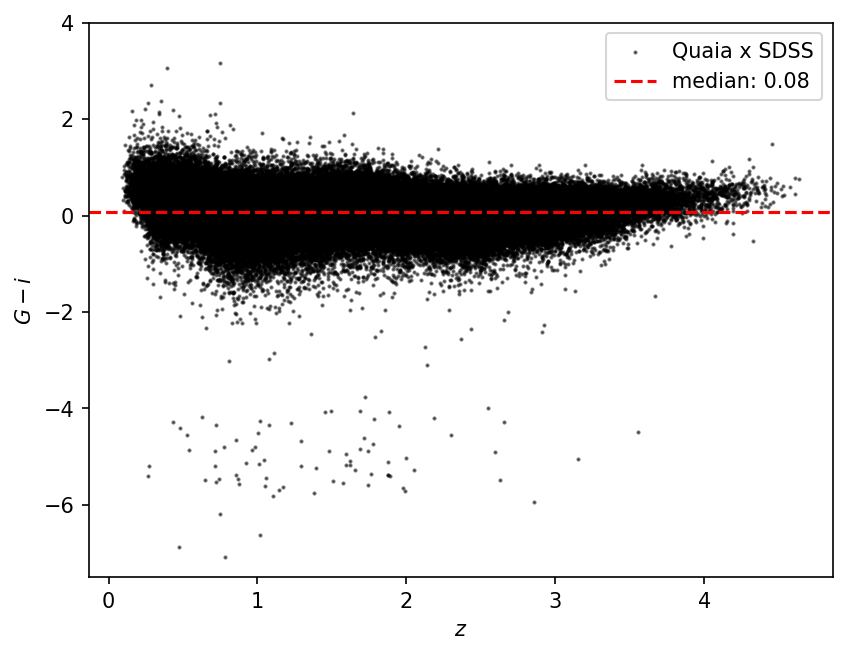

In [38]:
plt.scatter(tab_quaia_with_sdssdr16q_match['redshift_quaia'], 
            tab_quaia_with_sdssdr16q_match['G-i'], s = 1, alpha = 0.5, label = 'Quaia x SDSS', color = 'black')
plt.axhline(median, color = 'red', label = 'median: {:.2f}'.format(median), linestyle = '--')
plt.xlabel('$z$')
plt.ylabel('$G-i$')
plt.ylim(-7.5,4)
plt.legend()
plt.show()

[  0.  50. 100.]
zbins: [0.08373538 1.57388961 4.64528728]
n_zbins: 2
zmin: 0.09373538191722569
zmax: 1.5738763809204102
median G-i: 0.09882354736328125 +/- 63.9920768737793

[  0.  50. 100.]
zbins: [0.08373538 1.57388961 4.64528728]
n_zbins: 2
zmin: 1.5738896131515503
zmax: 4.635287284851074
median G-i: 0.06924629211425781 +/- 45.26306915283203



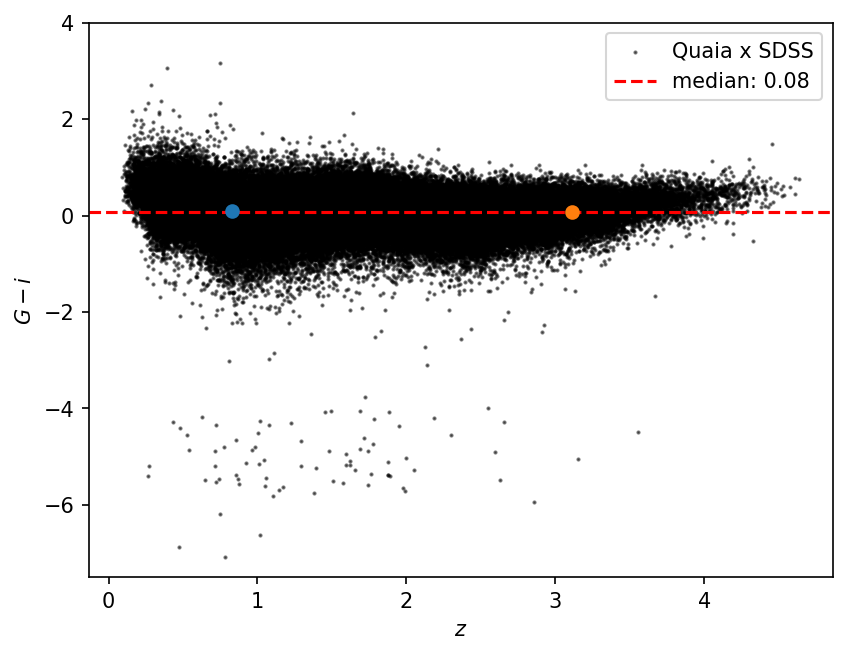

In [39]:
plt.scatter(tab_quaia_with_sdssdr16q_match['redshift_quaia'], 
            tab_quaia_with_sdssdr16q_match['G-i'], s = 1, alpha = 0.5, label = 'Quaia x SDSS', color = 'black')
plt.axhline(median, color = 'red', label = 'median: {:.2f}'.format(median), linestyle = '--')

n_zbins = 2
for i in range(n_zbins):
 #    (tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, 
 # key_zbin0) = quaia.zbins(G, i, tab_gcat = tab_quaia_with_sdssdr16q_match, data = 'mocks', n_zbins = n_zbins)
    (tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, 
 key_zbin0, z_bins) = quaia.make_zbins(G, i, False, method = 'zsplit', tab_gcat = tab_quaia_with_sdssdr16q_match, n_zbins = n_zbins)
    print('median G-i: {} +/- {}\n'.format(np.median(tab_datahi_mask_zbin0['G-i']), np.std(tab_datahi_mask_zbin0['G-i'])))
    plt.scatter(quaia.recenter(z_bins)[i], np.median(tab_datahi_mask_zbin0['G-i']), zorder = 3)
    
plt.xlabel('$z$')
plt.ylabel('$G-i$')
plt.ylim(-7.5,4)
plt.legend()
plt.show()

[  0.  25.  50.  75. 100.]
zbins: [0.08373538 1.0840863  1.57388961 2.16025043 4.64528728]
n_zbins: 4
zmin: 0.09373538191722569
zmax: 1.0840697288513184
median G-i: 0.10137271881103516 +/- 64.9765853881836

[  0.  25.  50.  75. 100.]
zbins: [0.08373538 1.0840863  1.57388961 2.16025043 4.64528728]
n_zbins: 4
zmin: 1.084086298942566
zmax: 1.5738763809204102
median G-i: 0.09364700317382812 +/- 53.37059020996094

[  0.  25.  50.  75. 100.]
zbins: [0.08373538 1.0840863  1.57388961 2.16025043 4.64528728]
n_zbins: 4
zmin: 1.5738896131515503
zmax: 2.160248041152954
median G-i: 0.10932540893554688 +/- 65.68944549560547

[  0.  25.  50.  75. 100.]
zbins: [0.08373538 1.0840863  1.57388961 2.16025043 4.64528728]
n_zbins: 4
zmin: 2.160250425338745
zmax: 4.635287284851074
median G-i: 0.019639968872070312 +/- 0.28601256012916565



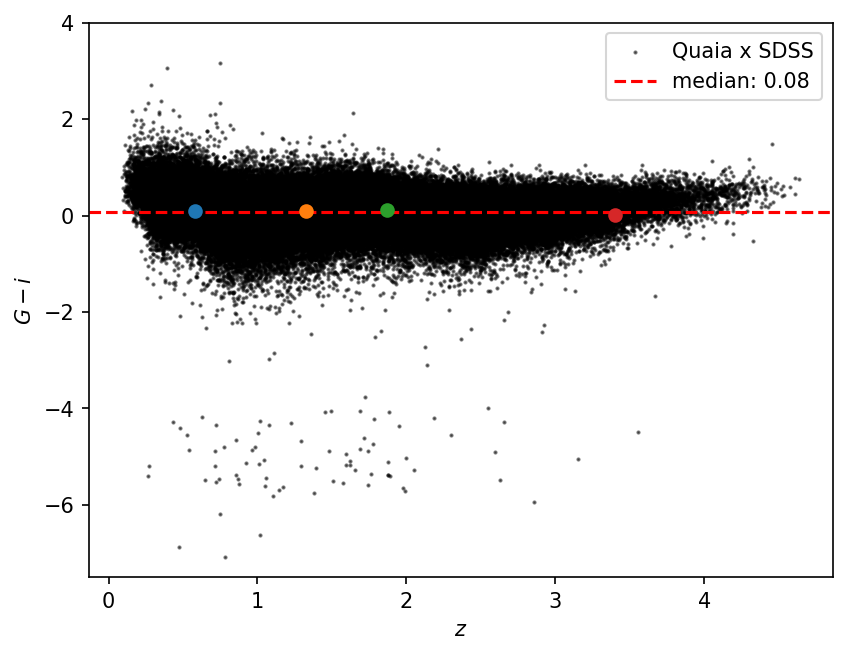

In [40]:
plt.scatter(tab_quaia_with_sdssdr16q_match['redshift_quaia'], 
            tab_quaia_with_sdssdr16q_match['G-i'], s = 1, alpha = 0.5, label = 'Quaia x SDSS', color = 'black')
plt.axhline(median, color = 'red', label = 'median: {:.2f}'.format(median), linestyle = '--')

n_zbins = 4
for i in range(n_zbins):
 #    (tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, 
 # key_zbin0) = quaia.zbins(G, i, tab_gcat = tab_quaia_with_sdssdr16q_match, data = 'mocks', n_zbins = n_zbins)
    (tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, 
 key_zbin0, z_bins) = quaia.make_zbins(G, i, False, method = 'zsplit', tab_gcat = tab_quaia_with_sdssdr16q_match, n_zbins = n_zbins)
    print('median G-i: {} +/- {}\n'.format(np.median(tab_datahi_mask_zbin0['G-i']), np.std(tab_datahi_mask_zbin0['G-i'])))
    plt.scatter(quaia.recenter(z_bins)[i], np.median(tab_datahi_mask_zbin0['G-i']), zorder = 3)
    
plt.xlabel('$z$')
plt.ylabel('$G-i$')
plt.ylim(-7.5,4)
plt.legend()
plt.show()

zmin: 0.09373538191722569
zmax: 0.999994158744812
median G-i: 0.1131134033203125 +/- 70.47467803955078

zmin: 1.0
zmax: 1.9999901056289673
median G-i: 0.10495758056640625 +/- 65.70347595214844

zmin: 2.0
zmax: 2.99995493888855
median G-i: 0.007355690002441406 +/- 0.2834637463092804

zmin: 3.000002861022949
zmax: 3.9994091987609863
median G-i: 0.13726139068603516 +/- 0.26968392729759216



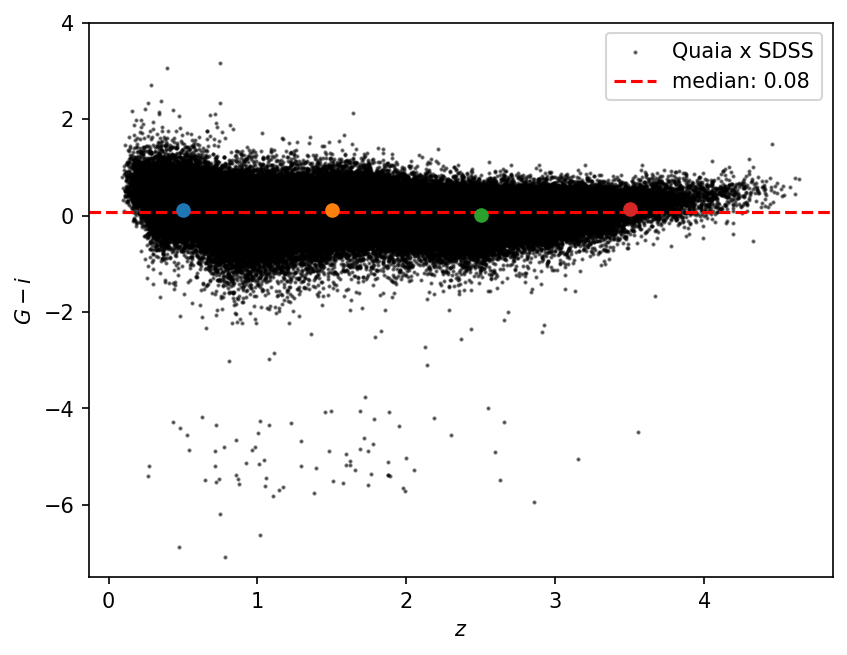

In [41]:
plt.scatter(tab_quaia_with_sdssdr16q_match['redshift_quaia'], 
            tab_quaia_with_sdssdr16q_match['G-i'], s = 1, alpha = 0.5, label = 'Quaia x SDSS', color = 'black')
plt.axhline(median, color = 'red', label = 'median: {:.2f}'.format(median), linestyle = '--')

z_bins = [0.0,1.0,2.0,3.0,4.0]
for bb in range(len(z_bins)-1):
    # i_zbin = (tab_quaia_with_sdssdr16q_match['redshift_quaia'] >= z_bins[bb]) & (tab_quaia_with_sdssdr16q_match['redshift_quaia'] < z_bins[bb+1])
    # tab_gcat_zbin = tab_quaia_with_sdssdr16q_match[i_zbin]
 #    (tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, 
 # key_zbin0) = quaia.zbins(G, bb, tab_gcat = tab_quaia_with_sdssdr16q_match, data = 'mocks', n_zbins = None)
    (tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, 
 key_zbin0, z_bins) = quaia.make_zbins(G, bb, False, method = 'zminzmax', tab_gcat = tab_quaia_with_sdssdr16q_match, z_bins = z_bins)
    print('median G-i: {} +/- {}\n'.format(np.median(tab_datahi_mask_zbin0['G-i']), np.std(tab_datahi_mask_zbin0['G-i'])))
    plt.scatter(quaia.recenter(np.array(z_bins))[bb], np.median(tab_datahi_mask_zbin0['G-i']), zorder = 3)
    
plt.xlabel('$z$')
plt.ylabel('$G-i$')
plt.ylim(-7.5,4)
plt.legend()
plt.show()